## Testing Triskel-MC model selection with a small Gaussian problem 

	•	simulate data = white Gaussian noise + a random mixture of signals
	•	signals:
	•	Gaussian bumps: count ∈ {0,1,2} uniformly
	•	Tukey-window pulses: count ∈ {0,1} uniformly
	•	noise σ (“noise_sig”) ~ Uniform([1, Nsig_max])
	•	likelihood: d - \sum_j s_j(\theta_j) \sim \mathcal{N}(0,\sigma^2 I)

In [3]:

import matplotlib.pyplot  as plt
import numpy as np
from numpy.typing import ArrayLike

import pandas as pd
from dataclasses import dataclass

import jax
import jax.numpy as jnp
from jax import vmap, jit

from functools import partial


import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

plt.style.use(['seaborn-v0_8-ticks','seaborn-v0_8-deep'])

# %pylab inline

mpl.rcParams.update({'font.size': 16})
plt.rcParams['axes.grid'] = True
plt.rcParams["figure.figsize"] = (12,7)

%load_ext autoreload
%autoreload 2




import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

# plt.style.use(['seaborn-v0_8-ticks','seaborn-v0_8-deep'])

# %pylab inline

mpl.rcParams.update({'font.size': 16})
plt.rcParams['axes.grid'] = True
plt.rcParams["figure.figsize"] = (12,7)




%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:


def rng_from_seed(seed=0):
    return np.random.default_rng(seed)

def log_uniform(a, b, x):
    # log Uniform([a,b]) density for scalar/array x (returns -inf outside)
    x = np.asarray(x)
    out = np.full_like(x, -np.inf, dtype=float)
    m = (x >= a) & (x <= b)
    out[m] = -np.log(b - a)
    return out

In [5]:
def gaussian_signal(x, A, sigma, x0):
    return A * np.exp(-0.5 * ((x - x0) / sigma) ** 2)

def tukey_window_1d(N, alpha):
    """
    Standard Tukey window of length N with taper fraction alpha in [0,1].
    Returns w[n] for n=0..N-1.
    """
    if N <= 1:
        return np.ones((N,), dtype=float)
    alpha = float(alpha)
    alpha = np.clip(alpha, 0.0, 1.0)
    if alpha == 0.0:
        return np.ones((N,), dtype=float)
    if alpha == 1.0:
        # Hann
        n = np.arange(N)
        return 0.5 * (1 - np.cos(2*np.pi*n/(N-1)))

    n = np.arange(N)
    w = np.ones((N,), dtype=float)
    edge = int(np.floor(alpha*(N-1)/2.0))

    # rising edge
    if edge > 0:
        n0 = np.arange(edge)
        w[n0] = 0.5 * (1 + np.cos(np.pi*( (2*n0)/(alpha*(N-1)) - 1 )))
        # falling edge
        n1 = np.arange(N-edge, N)
        k = n1 - (N-edge)
        w[n1] = 0.5 * (1 + np.cos(np.pi*( (2*(N-1-n1))/(alpha*(N-1)) - 1 )))
    return w

def tukey_pulse(x, A, width, alpha, x0):
    """
    Tukey-window 'pulse' centered near x0 with total support ~width.
    Implemented by placing a Tukey window on the nearest integer support.
    """
    width = float(width)
    if width <= 0:
        return np.zeros_like(x, dtype=float)

    # integer support indices
    half = 0.5 * width
    i0 = int(np.floor(x0 - half))
    i1 = int(np.ceil (x0 + half))
    i0 = max(i0, 0)
    i1 = min(i1, int(x[-1]) if np.all(np.isclose(np.diff(x), 1.0)) else len(x)-1)
    # convert to index range in x-array (assume x = 0..L-1 integer grid)
    i0 = max(i0, 0)
    i1 = min(i1, len(x)-1)

    N = i1 - i0 + 1
    if N <= 0:
        return np.zeros_like(x, dtype=float)

    w = tukey_window_1d(N, alpha)
    y = np.zeros_like(x, dtype=float)
    y[i0:i1+1] = A * w
    return y

In [6]:
@dataclass
class SimConfig:
    L: int = 512
    # noise sigma prior
    Nsig_max: float = 5.0

    # gaussian signal priors
    sig_min: float = 2.0
    sig_max: float = 10.0
    x_min: float = 50.0
    x_max: float = 500.0  # should be < L
    A_scale: float = 5.0  # amplitude prior is Uniform([0, A_scale*Nsig_max])

    # tukey priors
    w_min: float = 10.0
    w_max: float = 100.0
    alpha_min: float = 0.05
    alpha_max: float = 0.95



### Make a dataset



	•	noise_sig ~ U(1, Nsig_max)
	•	n_gauss ∈ {0,1,2} uniform
	•	n_tukey ∈ {0,1} uniform

In [7]:
def sample_ground_truth(rng, cfg: SimConfig):
    L = cfg.L
    x = np.arange(L, dtype=float)

    noise_sig = rng.uniform(1.0, cfg.Nsig_max)

    # counts
    n_gauss = int(rng.integers(0, 3))  # 0,1,2
    n_tukey = int(rng.integers(0, 2))  # 0,1

    gauss_params = []
    for _ in range(n_gauss):
        A = rng.uniform(0.0, cfg.A_scale * cfg.Nsig_max)
        sig = rng.uniform(cfg.sig_min, cfg.sig_max)
        x0 = rng.uniform(cfg.x_min, min(cfg.x_max, L-1.0))
        gauss_params.append((A, sig, x0))

    tukey_params = []
    for _ in range(n_tukey):
        A = rng.uniform(0.0, cfg.A_scale * cfg.Nsig_max)
        w = rng.uniform(cfg.w_min, cfg.w_max)
        alpha = rng.uniform(cfg.alpha_min, cfg.alpha_max)
        x0 = rng.uniform(cfg.x_min, min(cfg.x_max, L-1.0))
        tukey_params.append((A, w, alpha, x0))

    # build signal
    s = np.zeros(L, dtype=float)
    for (A, sig, x0) in gauss_params:
        s += gaussian_signal(x, A, sig, x0)
    for (A, w, alpha, x0) in tukey_params:
        s += tukey_pulse(x, A, w, alpha, x0)

    # noise + data
    n = rng.normal(0.0, noise_sig, size=L)
    d = s + n

    truth = {
        "noise_sig": noise_sig,
        "gauss_params": gauss_params,   # list of tuples
        "tukey_params": tukey_params,   # list of tuples
        "signal": s,
        "noise": n,
        "data": d,
    }
    return x, truth

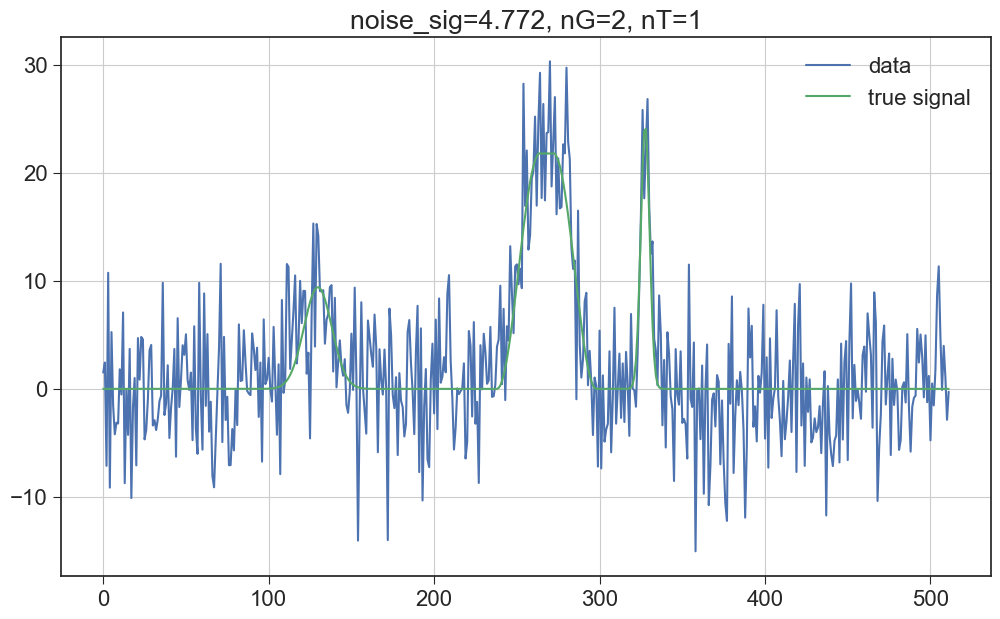

Gaussian ['A', 'sig', 'x0'] 
 [(24.406092642692602, 2.6466881911648175, 327.5616152217285), (9.412164609431814, 8.415209655886457, 129.759211977821)]
Tukey ['A', 'w', 'alpha', 'x0'] 
 [(21.79088185469141, 58.954726068714834, 0.8619935717443894, 268.0591603945173)]


In [12]:
cfg = SimConfig(L=512, Nsig_max=5.0, x_max=507.0)
rng = rng_from_seed(4)

x, truth = sample_ground_truth(rng, cfg)

plt.figure()
plt.plot(x, truth["data"], label="data")
plt.plot(x, truth["signal"], label="true signal")
plt.legend()
plt.title(f"noise_sig={truth['noise_sig']:.3f}, nG={len(truth['gauss_params'])}, nT={len(truth['tukey_params'])}")
plt.show()

Gaussian_params = ["A", "sig", "x0"]
Tukey_params = ["A", "w", "alpha", "x0"]

print ("Gaussian", Gaussian_params, "\n", truth["gauss_params"])
print ("Tukey", Tukey_params, "\n", truth["tukey_params"])

### Likelihood and log posterior pieces (Point 2)



We’ll represent a candidate model by:

	•	noise_sig (always present)
	•	gauss_params: list of up to 2 Gaussian components (active ones)
	•	tukey_params: list of up to 1 Tukey component (active ones)

In [13]:
def synthesize_signal(x, gauss_params, tukey_params):
    s = np.zeros_like(x, dtype=float)
    for (A, sig, x0) in gauss_params:
        s += gaussian_signal(x, A, sig, x0)
    for (A, w, alpha, x0) in tukey_params:
        s += tukey_pulse(x, A, w, alpha, x0)
    return s

def loglik_gaussian_iid(d, s, noise_sig):
    """
    d = s + n, n ~ N(0, noise_sig^2 I)
    """
    noise_sig = float(noise_sig)
    if noise_sig <= 0 or not np.isfinite(noise_sig):
        return -np.inf
    r = d - s
    L = r.size
    return -0.5 * (np.sum(r*r) / (noise_sig**2) + L*np.log(2*np.pi*noise_sig**2))

In [14]:
def logprior_noise(noise_sig, cfg: SimConfig):
    return float(log_uniform(1.0, cfg.Nsig_max, noise_sig))

def logprior_gauss_component(A, sig, x0, cfg: SimConfig):
    lp = 0.0
    lp += float(log_uniform(0.0, cfg.A_scale*cfg.Nsig_max, A))
    lp += float(log_uniform(cfg.sig_min, cfg.sig_max, sig))
    lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L-1.0), x0))
    return lp

def logprior_tukey_component(A, w, alpha, x0, cfg: SimConfig):
    lp = 0.0
    lp += float(log_uniform(0.0, cfg.A_scale*cfg.Nsig_max, A))
    lp += float(log_uniform(cfg.w_min, cfg.w_max, w))
    lp += float(log_uniform(cfg.alpha_min, cfg.alpha_max, alpha))
    lp += float(log_uniform(cfg.x_min, min(cfg.x_max, cfg.L-1.0), x0))
    return lp

def logprior_model(noise_sig, gauss_params, tukey_params, cfg: SimConfig):
    lp = logprior_noise(noise_sig, cfg)
    for (A, sig, x0) in gauss_params:
        lp += logprior_gauss_component(A, sig, x0, cfg)
    for (A, w, alpha, x0) in tukey_params:
        lp += logprior_tukey_component(A, w, alpha, x0, cfg)
    return float(lp)

In [16]:
print ("noise prior", logprior_noise(truth["noise_sig"], cfg))
for i, (A, sig, x0) in enumerate(truth["gauss_params"]):
    print (f"Gaussian {i} prior", logprior_gauss_component(A, sig, x0, cfg))
for i, (A, w, alpha, x0) in enumerate(truth["tukey_params"]):
    print (f"Tukey {i} prior", logprior_tukey_component(A, w, alpha, x0, cfg))

noise prior -1.3862943611198906
Gaussian 0 prior -11.423000757442242
Gaussian 1 prior -11.423000757442242
Tukey 0 prior -13.738008370434844


In [17]:
def logposterior(d, x, noise_sig, gauss_params, tukey_params, cfg: SimConfig):
    s = synthesize_signal(x, gauss_params, tukey_params)
    ll = loglik_gaussian_iid(d, s, noise_sig)
    if not np.isfinite(ll):
        return -np.inf
    lp = logprior_model(noise_sig, gauss_params, tukey_params, cfg)
    return lp + ll

In [20]:
print ("log posteriror", logposterior(truth["data"], x, truth["noise_sig"], truth["gauss_params"], truth["tukey_params"], cfg))

d = truth["data"]

lp_true = logposterior(
    d, x,
    truth["noise_sig"],
    truth["gauss_params"],
    truth["tukey_params"],
    cfg
)

lp_noise_only = logposterior(
    d, x,
    truth["noise_sig"],
    [], [],  # no signals
    cfg
)

print ("log posterior (true model)", lp_true)
print ("log posterior (noise only)", lp_noise_only) 

log posteriror -1566.2008375621438
log posterior (true model) -1566.2008375621438
log posterior (noise only) -1950.1984179844333


In [ ]:
# Later:
# Kmax = 4
# slot_dim  = [1, 3, 3, 4]
# slot_type = (user-defined labels like ["noise","gauss","gauss","tukey"] or ints)
# must_be_on = [True, False, False, False]
# can_toggle = [False, True, True, True]  # noise not toggled

print("Sampler integration will come next once we update Triskel-MC for typed slots + constraints.")